## Task 1 and 2

First 5 rows:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Shape: (1372, 5)

Missing values:
 variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Descriptive stats:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     

<Figure size 1000x800 with 0 Axes>

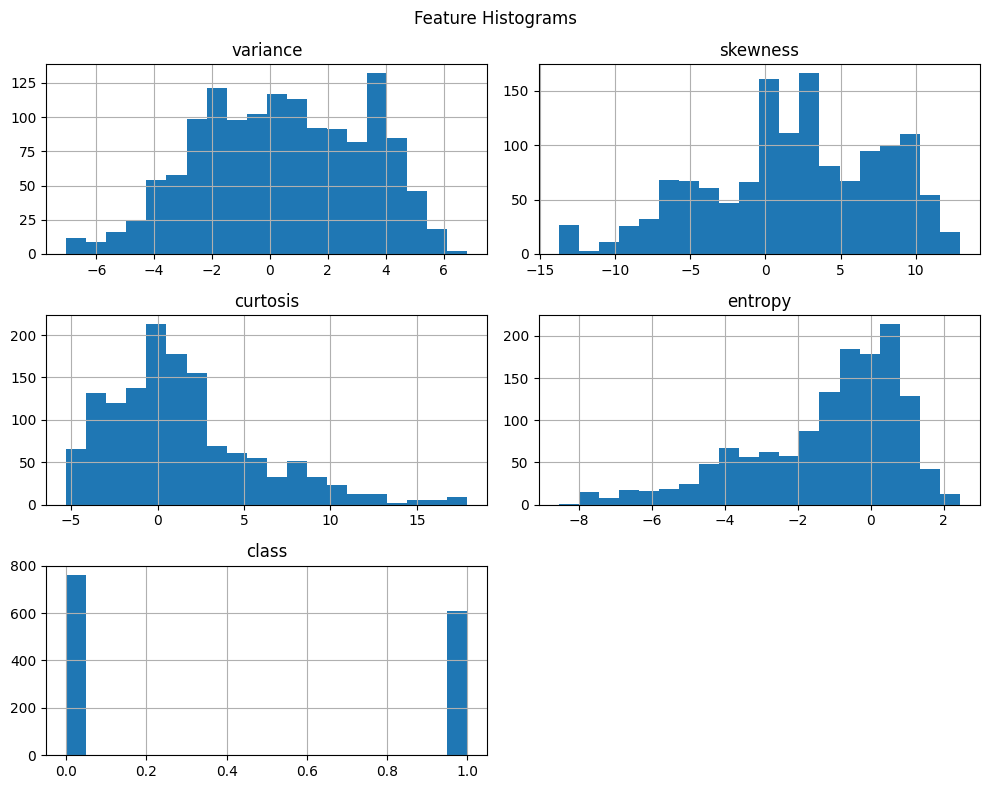

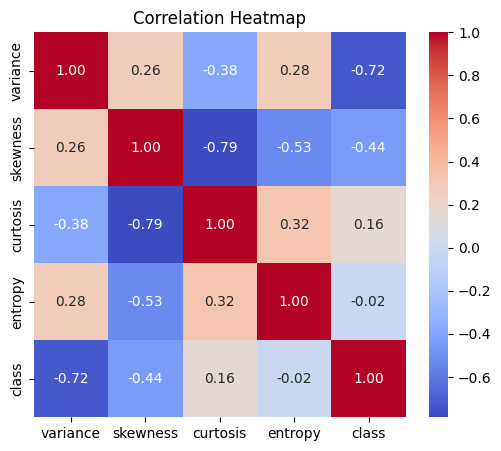

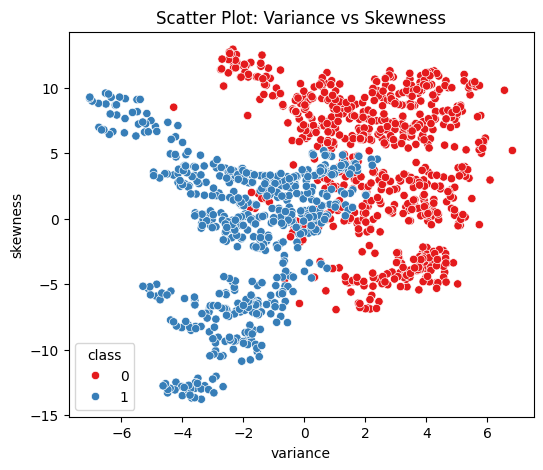

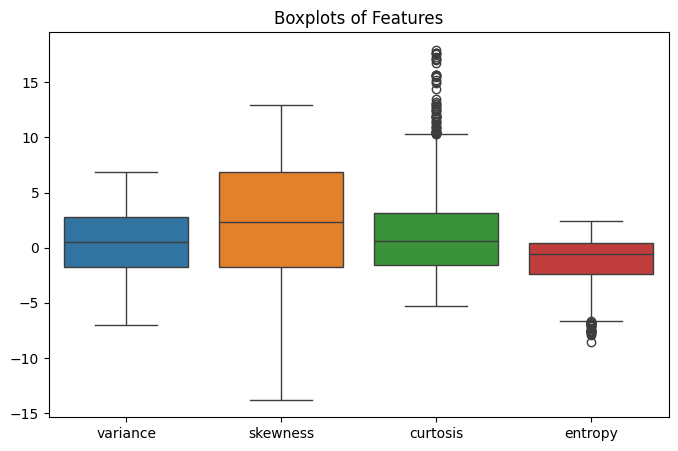

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron

# Task 1: Load dataset
# The raw UCI text file has no header, so we assign column names manually
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
cols = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(url, header=None, names=cols)

print("First 5 rows:")
print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive stats:")
print(df.describe())

# Task 2: Exploratory Data Analysis
plt.figure(figsize=(10, 8))
df.hist(bins=20, figsize=(10, 8))
plt.suptitle('Feature Histograms')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x='variance', y='skewness', hue='class', data=df, palette='Set1')
plt.title('Scatter Plot: Variance vs Skewness')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df.drop('class', axis=1))
plt.title('Boxplots of Features')
plt.show()

# **Task 3 and 4**

In [5]:
# Task 3: Data Preprocessing
X = df.drop('class', axis=1).values
y = df['class'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Task 4: Perceptron Implementation from scratch
class PerceptronScratch:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []
        self.weight_history = []
        self.bias_history = []

    def step_activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for epoch in range(self.epochs):
            errors = 0
            for idx, x_i in enumerate(X):
                z = np.dot(x_i, self.weights) + self.bias
                y_pred = self.step_activation(z)
                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update
                if update != 0:
                    errors += 1
            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"Epoch {epoch+1}: Misclassified = {errors}, Weights = {np.round(self.weights, 3)}, Bias = {self.bias:.4f}")

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_activation(z)

# **Task 5 and 6**


Training Custom Perceptron : 
Epoch 1: Misclassified = 47, Weights = [-0.073 -0.065 -0.064  0.   ], Bias = -0.0300
Epoch 10: Misclassified = 26, Weights = [-0.132 -0.156 -0.126  0.012], Bias = -0.0600
Epoch 20: Misclassified = 17, Weights = [-0.156 -0.175 -0.155 -0.026], Bias = -0.0900
Epoch 30: Misclassified = 18, Weights = [-0.176 -0.187 -0.179 -0.014], Bias = -0.1000
Epoch 40: Misclassified = 21, Weights = [-0.174 -0.215 -0.198 -0.015], Bias = -0.1000
Epoch 50: Misclassified = 13, Weights = [-0.197 -0.219 -0.211 -0.018], Bias = -0.1000

Evaluation Metrics : 
Accuracy: 0.9782
Precision: 0.9840
Recall: 0.9685
F1-score: 0.9762
Confusion Matrix:
 [[146   2]
 [  4 123]]


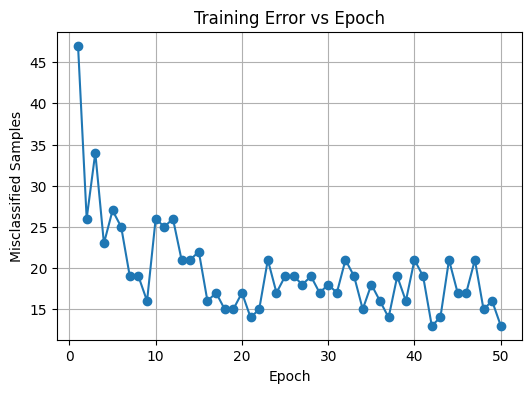

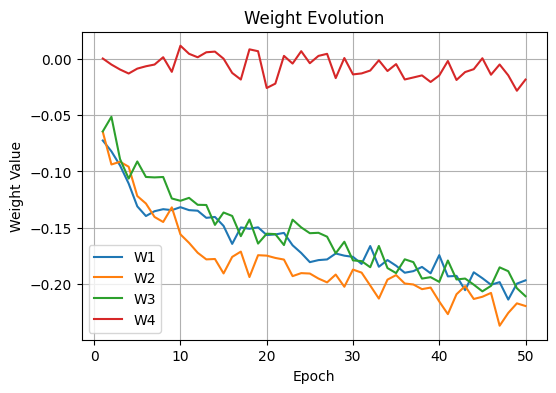

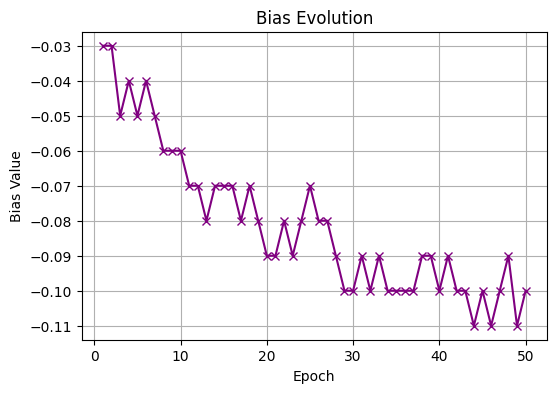

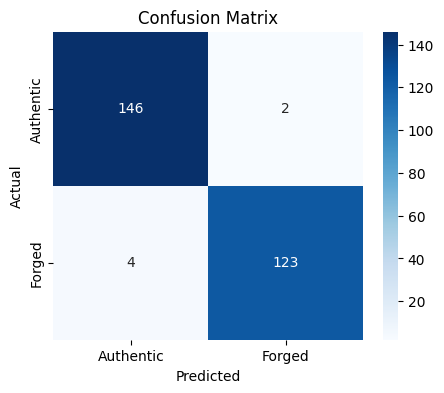


Learning Rate Comparison : 
Epoch 1: Misclassified = 47, Weights = [-0.007 -0.006 -0.006  0.   ], Bias = -0.0030
Epoch 10: Misclassified = 26, Weights = [-0.013 -0.016 -0.013  0.001], Bias = -0.0060
Epoch 20: Misclassified = 17, Weights = [-0.016 -0.017 -0.016 -0.003], Bias = -0.0090
Epoch 30: Misclassified = 18, Weights = [-0.018 -0.019 -0.018 -0.001], Bias = -0.0100
Epoch 40: Misclassified = 21, Weights = [-0.017 -0.022 -0.02  -0.001], Bias = -0.0100
Epoch 50: Misclassified = 13, Weights = [-0.02  -0.022 -0.021 -0.002], Bias = -0.0100
Epoch 1: Misclassified = 47, Weights = [-0.073 -0.065 -0.064  0.   ], Bias = -0.0300
Epoch 10: Misclassified = 26, Weights = [-0.132 -0.156 -0.126  0.012], Bias = -0.0600
Epoch 20: Misclassified = 17, Weights = [-0.156 -0.175 -0.155 -0.026], Bias = -0.0900
Epoch 30: Misclassified = 18, Weights = [-0.176 -0.187 -0.179 -0.014], Bias = -0.1000
Epoch 40: Misclassified = 21, Weights = [-0.174 -0.215 -0.198 -0.015], Bias = -0.1000
Epoch 50: Misclassified = 1

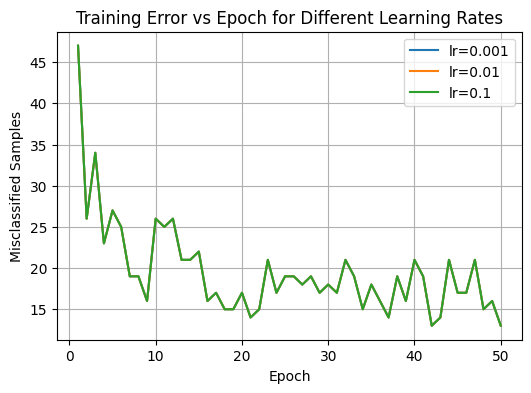

Epoch 1: Misclassified = 181, Weights = [-0.029 -0.002], Bias = 0.0100
Epoch 10: Misclassified = 172, Weights = [-0.024 -0.008], Bias = 0.0100
Epoch 20: Misclassified = 184, Weights = [-0.029 -0.001], Bias = 0.0100
Epoch 30: Misclassified = 176, Weights = [-0.029 -0.011], Bias = 0.0100
Epoch 40: Misclassified = 172, Weights = [-0.029 -0.011], Bias = 0.0100
Epoch 50: Misclassified = 174, Weights = [-0.025 -0.004], Bias = 0.0100


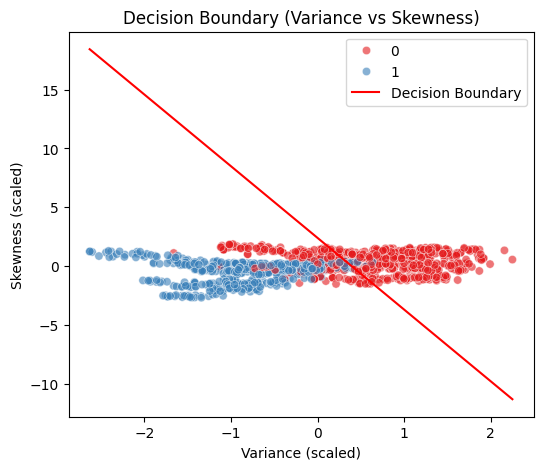

In [7]:
# Task 5 & 6: Training and Evaluation
print("\nTraining Custom Perceptron : ")
model = PerceptronScratch(lr=0.01, epochs=50)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nEvaluation Metrics : ")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

# Mandatory Plots
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(model.errors)+1), model.errors, marker='o')
plt.title('Training Error vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.grid(True)
plt.show()

weight_history_arr = np.array(model.weight_history)
plt.figure(figsize=(6, 4))
for i in range(weight_history_arr.shape[1]):
    plt.plot(range(1, len(model.errors)+1), weight_history_arr[:, i], label=f'W{i+1}')
plt.title('Weight Evolution')
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(model.errors)+1), model.bias_history, marker='x', color='purple')
plt.title('Bias Evolution')
plt.xlabel('Epoch')
plt.ylabel('Bias Value')
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Authentic', 'Forged'], yticklabels=['Authentic', 'Forged'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Learning Rate Comparison
print("\nLearning Rate Comparison : ")
lrs = [0.001, 0.01, 0.1]
plt.figure(figsize=(6, 4))
for lr in lrs:
    temp_model = PerceptronScratch(lr=lr, epochs=50)
    temp_model.fit(X_train, y_train)
    plt.plot(range(1, 51), temp_model.errors, label=f'lr={lr}')
plt.title('Training Error vs Epoch for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.legend()
plt.grid(True)
plt.show()

# Decision Boundary
X_2d = X_scaled[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

model_2d = PerceptronScratch(lr=0.01, epochs=50)
model_2d.fit(X_train_2d, y_train_2d)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train_2d, palette='Set1', alpha=0.6)
x_vals = np.array([X_2d[:, 0].min(), X_2d[:, 0].max()])
y_vals = -(model_2d.weights[0] * x_vals + model_2d.bias) / model_2d.weights[1]
plt.plot(x_vals, y_vals, color='red', label='Decision Boundary')
plt.title('Decision Boundary (Variance vs Skewness)')
plt.xlabel('Variance (scaled)')
plt.ylabel('Skewness (scaled)')
plt.legend()
plt.show()

# **Comparision with scikit learn**

In [9]:
# Comparision with Scikit-learn
print("\nScikit-learn Perceptron Comparison : ")
sklearn_model = Perceptron(eta0=0.01, max_iter=50, random_state=42)
sklearn_model.fit(X_train, y_train)
y_pred_sk = sklearn_model.predict(X_test)
print(f"Sklearn Accuracy: {accuracy_score(y_test, y_pred_sk):.4f}")
print(f"Sklearn Weights: {np.round(sklearn_model.coef_[0], 3)}, Bias: {np.round(sklearn_model.intercept_[0], 4)}")


--- Scikit-learn Perceptron Comparison ---
Sklearn Accuracy: 0.9891
Sklearn Weights: [-0.134 -0.127 -0.133 -0.005], Bias: -0.05
